In [1]:
import numpy as np
import torch

from rlaopt.solvers import PCGConfig, SAPConfig, SAPAccelConfig
from rlaopt.preconditioners import NystromConfig, NewtonConfig
from rlaopt.kernels import KernelConfig

from scalable_gp_inference.kernel_linsys import KernelLinSys

In [2]:
seed = 0
ntr = 1000
ntst = 200
d=10

In [3]:
torch.set_default_dtype(torch.float64)
torch.manual_seed(seed)

In [4]:
device = torch.device("cuda:0")

Xtr = torch.randn(ntr, d,device=device)
Xtst = torch.randn(ntst,d,device=device)

b = Xtr @ torch.randn((d,1),device=device) / (d)**(0.5) + 0.001 * torch.randn((ntr,1),device=device)

kernel_type = "rbf"
distributed = False
devices = set([torch.device("cuda:0")])
num_posterior_samples = 64
num_random_features = 2048

kernel_config = KernelConfig(const_scaling=1.0,lengthscale=5.0)

In [5]:
Ksys = KernelLinSys(
    Xtr, 
    b, 
    0.01,
    kernel_type="rbf", 
    kernel_config=kernel_config, 
    use_full_kernel=True,
    devices=devices
)

In [6]:
K = Ksys.A
Kmat = K @ torch.eye(ntr,device=device)

In [7]:
wStar = torch.linalg.solve(Kmat + 0.01 * torch.eye(ntr,device=device), b)

In [8]:
V, lambd, _ = torch.linalg.svd(Kmat)

In [9]:
ranks = [1, 10, 100, 1000]

In [10]:
w_list = []
num_iters = 0

In [11]:
def _evaluate_subspace_convergence(w, Ksys, V, wStar, ranks):
    results = {}
    d = w - wStar
    for r in ranks:
        Vr = V[:,0:r]
        dr = Vr.T @ d
        Kr = Vr.T @ (Ksys.A @ Vr)
        results[f"subspace_{r}"] = dr.T @ (Kr @ dr)
    return results

def _compute_tail_average(w_list):
    num_iters = len(w_list)

    print(f"Computing tail average over last {num_iters // 2} iterates.")

    tail_start = num_iters // 2
    tail_w_list = w_list[tail_start:num_iters]
    tail_avg = torch.mean(torch.stack(tail_w_list), dim=0)
    return tail_avg

def callback_fn(w, Ksys, V):
    w_list.append(w.clone())
    tail_avg = _compute_tail_average(w_list)

    results_non_averaged = _evaluate_subspace_convergence(w, Ksys, V, wStar, ranks)
    results_averaged = _evaluate_subspace_convergence(tail_avg, Ksys, V, wStar, ranks)

    results = {}
    for key in results_non_averaged:
        results[key] = {
            "non_averaged": results_non_averaged[key].item(),
            "averaged": results_averaged[key].item(),
        }

    return results

In [12]:
blk_sz = Xtr.shape[0] // 100

max_iters = 40 * Xtr.shape[0] // blk_sz

solver_config = SAPConfig(
    precond_config=NewtonConfig(rho=0.01),
    max_iters=max_iters,
    atol=1e-10,
    rtol=1e-10,
    blk_sz=blk_sz,
    accel=False,
    accel_config=None,
    device=torch.device("cuda:0"),
)


In [13]:
wStar, log = Ksys.solve(solver_config, torch.zeros_like(b), callback_fn=callback_fn, callback_args=[V])

Computing tail average over last 0 iterates.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
[pyKeOps] Warning : at least one of the input tensors is not contiguous. Consider using contiguous data arrays to avoid unnecessary copies.
Computing tail average over last 1 iterates.
[pyKeOps] Warning : at least one of the input tensors is not contiguou

In [14]:
subspace_errs = {}
for i in log:
    for key, value in log[i]["metrics"]["callback"].items():
        if key not in subspace_errs:
            subspace_errs[key] = []
        subspace_errs[key].append(value)

In [15]:
print(subspace_errs)

{'subspace_1': [{'non_averaged': 0.0008173460218443676, 'averaged': 0.0008173460218443676}, {'non_averaged': 6.242336432903215e-05, 'averaged': 6.242336432903215e-05}, {'non_averaged': 0.0025860585409873656, 'averaged': 0.0004612284191940188}, {'non_averaged': 5.685543757785946e-05, 'averaged': 0.00046900506757160064}, {'non_averaged': 0.00033864023020797527, 'averaged': 6.895015832470108e-05}, {'non_averaged': 0.0034177237235187186, 'averaged': 0.000791554509112118}, {'non_averaged': 5.422903955413177e-05, 'averaged': 0.0005263327543376773}, {'non_averaged': 0.0005599213973305173, 'averaged': 0.0007275181340318589}, {'non_averaged': 0.0026498066177812743, 'averaged': 0.001015906598695616}, {'non_averaged': 4.89883779764859e-05, 'averaged': 0.0007178659083112337}, {'non_averaged': 0.0006044584292173012, 'averaged': 0.0003323290264164452}, {'non_averaged': 0.000666560771648155, 'averaged': 0.00016356661958559032}, {'non_averaged': 0.0006694507269785868, 'averaged': 5.279507531710809e-05

In [16]:
import matplotlib.pyplot as plt

In [18]:
plt.rcParams.update({"text.usetex": True, "font.family": "serif"})

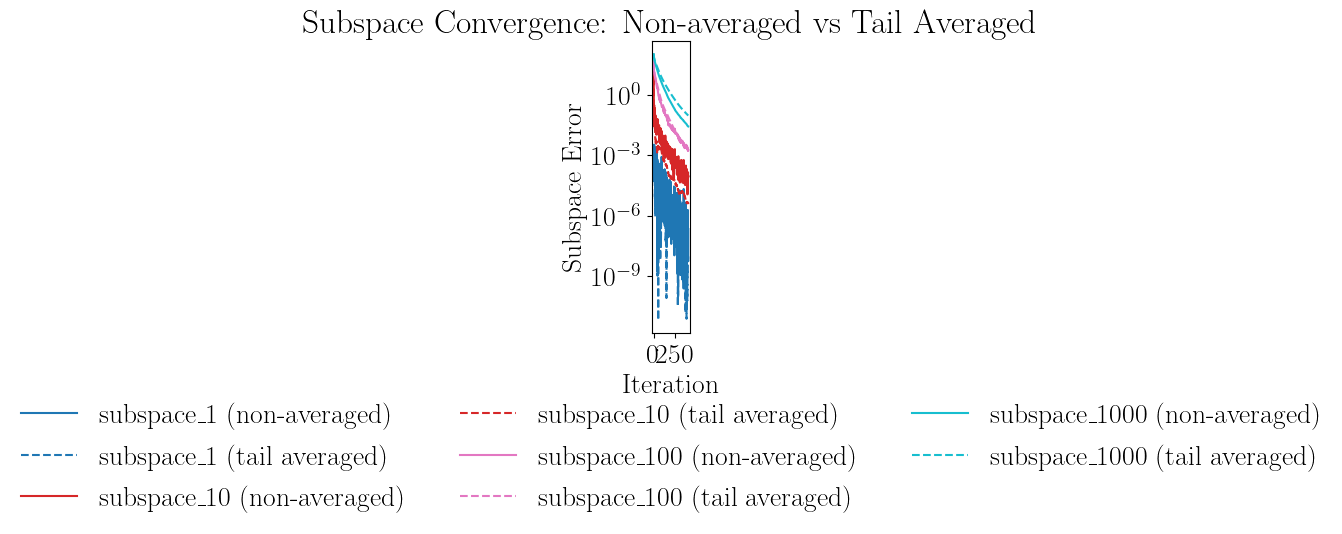

In [ ]:
# Set font size to match other figures (FONTSIZE = 20)
plt.rcParams.update({"font.size": 20})

# Use consistent figure size from plotting constants (SZ_COL=8, SZ_ROW=6)
plt.figure(figsize=(10, 6))

# Define colors for each rank to ensure consistency
colors = plt.cm.tab10(np.linspace(0, 1, len(subspace_errs)))
color_map = {key: colors[i] for i, key in enumerate(subspace_errs.keys())}

for key, value in subspace_errs.items():
    # Extract non-averaged and averaged values
    non_averaged = [v["non_averaged"] for v in value]
    averaged = [v["averaged"] for v in value]
    
    # Plot non-averaged with solid line using consistent color
    plt.semilogy(non_averaged, label=f"{key} (non-averaged)", linestyle='-', color=color_map[key])
    
    # Plot averaged with dashed line using same color
    plt.semilogy(averaged, label=f"{key} (tail averaged)", linestyle='--', color=color_map[key])

plt.xlabel('Iteration')
plt.ylabel('Subspace Error')
plt.title('Subspace Convergence: Non-averaged vs Tail Averaged')

# Position legend below the figure with more spacing to avoid overlap
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.show()